In [1]:
%load_ext autoreload
%autoreload 2
import jax.numpy as jnp

from popsim.simulators.comet_mirror.build_default import build_default
from popsim.simulators.comet_mirror.integrator import Integrator
import diffrax
import equinox as eqx
import jax
from popsim.trajectory import cubic_interp
from popsim.xarray import solution_to_xarray, time_and_pytree_to_xarray
from popsim.visualize import visualize_time_series
import holoviews as hv

hv.extension("matplotlib")

# Initialize the simulator.
model, state, params = build_default()
sim = Integrator(model)
ts = jnp.linspace(0, 2, 100)
ramprate = 1e6
current = params.plasma_current + -ramprate * ts

# Replace the constant current with a ramp.
params = eqx.tree_at(where=lambda p: p.plasma_current, pytree=params, replace=cubic_interp(ts, current))

/home/awang/repos/POPSIM/.venv/lib/python3.9/site-packages/xarray/core/variable.py:306: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
<frozen importlib._bootstrap>:228: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
/home/awang/repos/POPSIM/.venv/lib/python3.9/site-packages/xarray/core/variable.py:306: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/awang/repos/POPSIM/.venv/lib/python3.9/site-packages/xarray/core/variable.py:306: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/awang/repos/POPSIM/.venv/lib/python3.9/site-packages/xarray/core/variable.py:306: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/home/awang/repos/POPSIM/.venv/l

# Generate Random Walks for Particle Confinement Times

:Layout
   .NdOverlay.I   :NdOverlay   [episode]
      :Curve   [time]   ([<FuelSpecies.Tritium: -3>])
   .NdOverlay.II  :NdOverlay   [episode]
      :Curve   [time]   ([<FuelSpecies.Deuterium: -2>])
   .NdOverlay.III :NdOverlay   [episode]
      :Curve   [time]   ([<Impurity.Helium: 2>])
   .NdOverlay.IV  :NdOverlay   [episode]
      :Curve   [time]   ([<Impurity.Oxygen: 8>])
   .NdOverlay.V   :NdOverlay   [episode]
      :Curve   [time]   ([<Impurity.Tungsten: 74>])
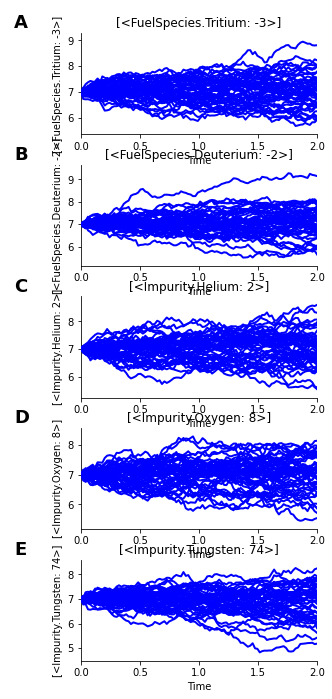

In [2]:
from popsim.stochastic import generate_random_walks

diffusion_mags = {k: 0.5 for k in params.particle_confinement_scalar.keys()}
n_samps = 50
sols = generate_random_walks(
    jax.random.PRNGKey(42),
    n_samps,
    ts,
    params.particle_confinement_scalar,
    diffusion_mags,
)
k_particle_trajs = {k: cubic_interp(sols.ts[0], sols.ys[k].T) for k in sols.ys}
visualize_time_series(solution_to_xarray(sols, True)).cols(1)

# Build a list of parameters, one for each random walk trajectory.

In [3]:
from popsim.tree_util import tree_transpose


def build_params_for_samp(i):
    particle_confinement_random = jax.tree_map(lambda x: x[i], sols.ys)
    particle_confinement_traj = {k: cubic_interp(sols.ts[0], particle_confinement_random[k]) for k in particle_confinement_random}
    return eqx.tree_at(
        where=lambda p: p.particle_confinement_scalar,
        pytree=params,
        replace=particle_confinement_traj,
    )


# Build a list of random params.
params_list = [build_params_for_samp(i) for i in range(n_samps)]

# Tree-transpose is important for vectorizing the simulator.
params_vectorized = tree_transpose(params_list)

# Vectorized simulation across the list of parameters.

In [4]:
def simulate_across_random_params(params):
    # For whatever reason we need this to make debug_info work.
    return sim(ts, state, params, debug_info=True)


params_axes = jax.tree_map(lambda x: 0, params_vectorized)
sol, debugs = jax.vmap(
    simulate_across_random_params,
    in_axes=(params_axes,),
)(params_vectorized)

# Visualize the simulation state results along with some debug variables

:Layout
   .NdOverlay.I    :NdOverlay   [episode]
      :Curve   [time]   (stored_energy)
   .NdOverlay.II   :NdOverlay   [episode]
      :Curve   [time]   (density_state.volume_average_ion_densities.[<FuelSpecies.Tritium: -3>])
   .NdOverlay.III  :NdOverlay   [episode]
      :Curve   [time]   (density_state.volume_average_ion_densities.[<FuelSpecies.Deuterium: -2>])
   .NdOverlay.IV   :NdOverlay   [episode]
      :Curve   [time]   (density_state.volume_average_ion_densities.[<Impurity.Helium: 2>])
   .NdOverlay.V    :NdOverlay   [episode]
      :Curve   [time]   (density_state.volume_average_ion_densities.[<Impurity.Oxygen: 8>])
   .NdOverlay.VI   :NdOverlay   [episode]
      :Curve   [time]   (density_state.volume_average_ion_densities.[<Impurity.Tungsten: 74>])
   .NdOverlay.VII  :NdOverlay   [episode]
      :Curve   [time]   (['plasma_current'])
   .NdOverlay.VIII :NdOverlay   [episode]
      :Curve   [time]   (['z_effective'])
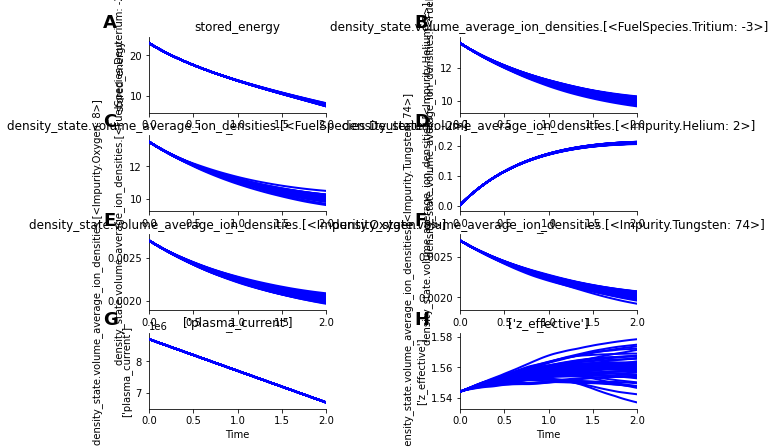

In [5]:
debug_vars = {
    "plasma_current": debugs["params"].plasma_current,
    "z_effective": debugs["z_effective"],
}
ds_debugs = time_and_pytree_to_xarray(sol.ts, debug_vars, True)

dataset = solution_to_xarray(sol, multi_episode=True)

dataset = dataset.merge(ds_debugs)
visualize_time_series(dataset).cols(2)